# Lab 3 - Part 2: Word and Sentence Embeddings

**Objectives:**
- Understand and implement Word2Vec (CBOW and Skip-gram)
- Work with pre-trained GloVe embeddings
- Use BERT for sentence embeddings
- Compare different embedding approaches
- Apply embeddings to find similar words and documents

---

## Instructions

1. Complete all exercises marked with `# YOUR CODE HERE`
2. **Answer all written questions** in the designated markdown cells
3. Save your completed notebook
4. **Push to your Git repository and send the link to: yoroba93@gmail.com**

### Important: This lab continues from Part 1

You will use the same dataset and categories you chose in Part 1.

---

## Setup

In [ ]:
# Install required libraries (uncomment if needed)
# !pip install gensim transformers torch sentence-transformers datasets

In [6]:
!pip install --upgrade gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 37.6 MB/s eta 0:00:00


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import re
import string
import warnings
warnings.filterwarnings('ignore')

import nltk
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from gensim.models import Word2Vec, KeyedVectors
import gensim
import gensim.downloader as api
print(f"Gensim version: {gensim.__version__}")
print("Setup complete!")

Gensim version: 4.4.0
Setup complete!


## Load Dataset (Same as Part 1)

In [10]:
import pandas as pd
from datasets import load_dataset

# Load the dataset
df = load_dataset("SetFit/20_newsgroups", split="train").to_pandas() # YOUR CODE HERE

# TODO: Use the SAME 3 categories you chose in Part 1!
my_categories = ["comp.graphics", "sci.space", "rec.sport.baseball"]  # COPY FROM PART 1

# Filter dataset
df_filtered = df[df['label_text'].isin(my_categories)].copy()
df_filtered = df_filtered.reset_index(drop=True)

print(f"Selected categories: {my_categories}")
print(f"Filtered dataset size: {len(df_filtered)}")

README.md:   0%|          | 0.00/734 [00:00<?, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


train.jsonl:   0%|          | 0.00/14.8M [00:00<?, ?B/s]

test.jsonl:   0%|          | 0.00/8.91M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/11314 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7532 [00:00<?, ? examples/s]

Selected categories: ['comp.graphics', 'sci.space', 'rec.sport.baseball']
Filtered dataset size: 1774


In [16]:
import nltk

# Forzar descarga de todos los recursos necesarios
nltk.download('punkt')       # Tokenizer básico
nltk.download('punkt_tab')   # Para algunos tokenizers más recientes que lo requieren
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [17]:
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import nltk

# Descargar recursos necesarios de NLTK
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')

# Preprocessing function (same as Part 1)
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    """Preprocess text for embedding training."""
    # YOUR CODE HERE
    text = text.lower()
    text = re.sub(r'\S+@\S+', ' ', text)             # Emails
    text = re.sub(r'http\S+|www.\S+', ' ', text)     # URLs
    text = re.sub(r'[^a-z\s]', ' ', text)           # Solo letras

    # YOUR CODE HERE
    tokens = nltk.word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]

    return tokens  # Return list of tokens for Word2Vec

# Apply preprocessing
df_filtered['tokens'] = df_filtered['text'].apply(preprocess_text)
df_filtered['text_clean'] = df_filtered['tokens'].apply(' '.join)

print(f"Sample tokens: {df_filtered.iloc[0]['tokens'][:20]}")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Sample tokens: ['weitek', 'address', 'phone', 'number', 'like', 'get', 'information', 'chip']


---

## Part A: Word2Vec - Training Your Own Embeddings

Word2Vec learns word representations by predicting context. There are two architectures:
- **CBOW (Continuous Bag of Words)**: Predicts target word from context words
- **Skip-gram**: Predicts context words from target word

### A.1 Understanding Word2Vec Architectures

In [18]:
# Prepare corpus for Word2Vec (list of tokenized sentences)
corpus = df_filtered['tokens'].tolist()

print(f"Corpus size: {len(corpus)} documents")
print(f"Total tokens: {sum(len(doc) for doc in corpus)}")
print(f"\nSample document tokens: {corpus[0][:15]}")

Corpus size: 1774 documents
Total tokens: 151264

Sample document tokens: ['weitek', 'address', 'phone', 'number', 'like', 'get', 'information', 'chip']


In [19]:
# Train Word2Vec with CBOW (sg=0)
model_cbow = Word2Vec(
    sentences=corpus,
    vector_size=100,      # Embedding dimension
    window=5,             # Context window size
    min_count=5,          # Ignore words with freq < 5
    workers=4,            # Parallel threads
    sg=0,                 # 0 = CBOW, 1 = Skip-gram
    epochs=10             # Training epochs
)

print(f"CBOW Model trained!")
print(f"Vocabulary size: {len(model_cbow.wv)}")

CBOW Model trained!
Vocabulary size: 4672


In [20]:
# Train Word2Vec with Skip-gram (sg=1)
model_skipgram = Word2Vec(
    sentences=corpus,
    vector_size=100,
    window=5,
    min_count=5,
    workers=4,
    sg=1,                 # Skip-gram
    epochs=10
)

print(f"Skip-gram Model trained!")
print(f"Vocabulary size: {len(model_skipgram.wv)}")

Skip-gram Model trained!
Vocabulary size: 4672


### A.2 Exploring Word Embeddings

In [21]:
# Example: Get word vector
sample_word = "computer"  # Change this to a word relevant to YOUR categories

if sample_word in model_cbow.wv:
    vector = model_cbow.wv[sample_word]
    print(f"Vector for '{sample_word}':")
    print(f"  Shape: {vector.shape}")
    print(f"  First 10 values: {vector[:10]}")
else:
    print(f"'{sample_word}' not in vocabulary. Try another word.")
    print(f"Sample words in vocab: {list(model_cbow.wv.key_to_index.keys())[:20]}")

Vector for 'computer':
  Shape: (100,)
  First 10 values: [-0.03422682  0.4228307   0.09710422 -0.33708686 -0.19564962 -0.9457205
 -0.00941169  1.6810917   0.47666854 -0.06680433]


In [22]:
# Find similar words
sample_word = "computer"  # Change to a word in YOUR vocabulary

if sample_word in model_cbow.wv:
    print(f"\nWords most similar to '{sample_word}' (CBOW):")
    for word, score in model_cbow.wv.most_similar(sample_word, topn=10):
        print(f"  {word}: {score:.4f}")

    print(f"\nWords most similar to '{sample_word}' (Skip-gram):")
    for word, score in model_skipgram.wv.most_similar(sample_word, topn=10):
        print(f"  {word}: {score:.4f}")


Words most similar to 'computer' (CBOW):
  visualization: 0.9619
  application: 0.9510
  user: 0.9504
  ray: 0.9486
  virtual: 0.9452
  ibm: 0.9438
  software: 0.9418
  sgi: 0.9416
  database: 0.9414
  interactive: 0.9374

Words most similar to 'computer' (Skip-gram):
  exponent: 0.7352
  switzerland: 0.7310
  acm: 0.7280
  ieee: 0.7200
  graeme: 0.7120
  resource: 0.7102
  bibliography: 0.7006
  siggraph: 0.6890
  silicon: 0.6823
  programmer: 0.6815


### Exercise A.1: Compare CBOW vs Skip-gram

Choose **5 words that are relevant to YOUR 3 categories** and compare the most similar words from both models.

In [23]:
# TODO: Choose 5 words relevant to YOUR categories
# These should be domain-specific words (not common words like "good", "make", etc.)

my_test_words = ["one", "space", "image", "year", "file"]  # YOUR WORDS HERE

comparison_results = []

for word in my_test_words:
    word = word.lower()
    if word in model_cbow.wv and word in model_skipgram.wv:
        cbow_similar = [w for w, s in model_cbow.wv.most_similar(word, topn=5)]
        skipgram_similar = [w for w, s in model_skipgram.wv.most_similar(word, topn=5)]

        comparison_results.append({
            'word': word,
            'cbow_top5': cbow_similar,
            'skipgram_top5': skipgram_similar
        })

        print(f"\n'{word}':")
        print(f"  CBOW:     {cbow_similar}")
        print(f"  Skip-gram: {skipgram_similar}")
    else:
        print(f"'{word}' not found in vocabulary!")


'one':
  CBOW:     ['come', 'actually', 'though', 'far', 'pretty']
  Skip-gram: ['least', 'expanded', 'smiley', 'surely', 'speculation']

'space':
  CBOW:     ['nasa', 'shuttle', 'national', 'technology', 'center']
  Skip-gram: ['jsc', 'astro', 'mnemonic', 'revision', 'activist']

'image':
  CBOW:     ['display', 'using', 'video', 'screen', 'manipulation']
  Skip-gram: ['setting', 'lossless', 'saving', 'pnmtops', 'photograph']

'year':
  CBOW:     ['second', 'day', 'last', 'league', 'lost']
  Skip-gram: ['season', 'lavalliere', 'decade', 'shown', 'month']

'file':
  CBOW:     ['format', 'gif', 'temp', 'pcx', 'jpeg']
  Skip-gram: ['jfif', 'format', 'hsi', 'ppm', 'pict']


### Written Question A.1 (Personal Interpretation)

Based on your comparison above:

1. **For which words did CBOW and Skip-gram give SIMILAR results?**
2. **For which words did they give DIFFERENT results?**
3. **Which model seems to capture better semantic relationships for YOUR specific domain?** Explain with examples.
4. **Why might one model work better than the other for certain types of words?** (Think about word frequency)

**YOUR ANSWER:**

1. Similar results for: Looking at the output, none of the five words have highly overlapping top-5 lists. However, “file” shows some partial similarity because both models suggest terms related to file formats (“format” appears in both). So we could say “file” is the word with the most similar results.


2. Different results for: one” - CBOW gives generic/common words; Skip-gram gives very unusual/unrelated words.
“space” - CBOW suggests NASA-related words (relevant), while Skip-gram has very domain-specific abbreviations or less common terms.
“image” - CBOW gives terms about display and manipulation, Skip-gram gives technical file or processing words.
“year” - CBOW focuses on temporal/common words (day, second, last), Skip-gram gives terms related to seasons, decades, or proper nouns.

3. Better model for my domain: For the categories i chose (computing, space, and sports), CBOW seems better for most words because it captures more general semantic relationships that make sense in context:

   - Example 1: “space” - CBOW - [‘nasa’, ‘shuttle’, ‘national’, ‘technology’, ‘center’] - clearly related to space/astronomy.
   - Example 2: “image” - CBOW -[‘display’, ‘using’, ‘video’, ‘screen’, ‘manipulation’] - clearly related to graphics/computing.

Skip-gram sometimes suggests  unusual words that may be too specific or not intuitive, which could be less useful in this case for tha analysis.

4. Explanation of differences: CBOW looks at the words around a word to guess it. It works better for common words and finds general meanings.
Skip-gram looks at a word to guess the words around it. It works better for rare or special words because it focuses on unusual words.
Example: “space” - CBOW gives normal space words like ‘nasa’ and ‘shuttle’. Skip-gram gives rare abbreviations like ‘jsc’ or ‘mnemonic’.

### A.3 Word Analogies

In [32]:
# Example: Word analogies (king - man + woman = queen)
# This works better with larger, pre-trained models, but let's try with our custom model

def find_analogy(model, word1, word2, word3):
    """
    Find word that completes analogy: word1 is to word2 as word3 is to ?
    Uses: word2 - word1 + word3 = ?
    """
    try:
        result = model.wv.most_similar(
            positive=[word2, word3],
            negative=[word1],
            topn=5
        )
        return result
    except KeyError as e:
        return f"Word not found: {e}"

# Test with your domain
# Example: "baseball" is to "bat" as "hockey" is to ?
print("Analogy test (your model may have limited vocabulary):")
# result = find_analogy(model_skipgram, "word1", "word2", "word3")
result3 = find_analogy(model_skipgram, "image", "pixel", "video")
print("image : pixel :: video : ?", result3)

# print(result)

Analogy test (your model may have limited vocabulary):
image : pixel :: video : ? [('clock', 0.7423415184020996), ('frame', 0.7385309338569641), ('super', 0.7339553833007812), ('colour', 0.7317957878112793), ('mode', 0.7275987267494202)]


### Exercise A.2: Create Domain-Specific Analogies

Try to find **2 analogies** that work with YOUR dataset's vocabulary.

In [35]:
# TODO: Try 2 analogies with words from YOUR vocabulary
# Format: word1 is to word2 as word3 is to ?

# Analogy 1
# YOUR CODE HERE
analogy1 = find_analogy(model_skipgram, "baseball", "team", "player")
print(f"Analogy 1: {analogy1}")

# Analogy 2
# YOUR CODE HERE
analogy2 = find_analogy(model_skipgram, "space", "nasa", "image")
print(f"Analogy 2: {analogy2}")

Analogy 1: [('total', 0.6364107728004456), ('offensive', 0.6250483393669128), ('rbi', 0.6225125789642334), ('winning', 0.6066051721572876), ('contribution', 0.6041683554649353)]
Analogy 2: [('select', 0.5001128911972046), ('sheet', 0.4945797622203827), ('setting', 0.49131420254707336), ('export', 0.48597216606140137), ('gov', 0.48545536398887634)]


### Written Question A.2 (Personal Interpretation)

**Did your analogies work?**
- If yes, explain why the result makes sense.
- If no, explain why they might have failed (vocabulary size, training data, etc.)

**YOUR ANSWER:**

*[Analyze your analogy results]*
My analogies did not work very well. The model sometimes gave strange or unrelated words. This happened because the model only knows words it saw in the small dataset, and some words we used were not in the vocabulary. Also, the dataset is small and has only three categories, so the model did not have enough examples to learn strong relationships between words.

---

## Part B: Pre-trained GloVe Embeddings

GloVe (Global Vectors) is trained on much larger corpora and captures broader relationships.

In [39]:
# Load pre-trained GloVe embeddings (this may take a few minutes)
print("Loading GloVe embeddings (this may take a minute)...")
glove_model = api.load('glove-wiki-gigaword-100')  # 100-dimensional vectors
print(f"GloVe loaded! Vocabulary size: {len(glove_model)}")

Loading GloVe embeddings (this may take a minute)...
[==================================================] 100.0% 128.1/128.1MB downloaded
GloVe loaded! Vocabulary size: 400000


In [40]:
# Compare: Same word in YOUR model vs GloVe
test_word = "team"  # Change to a word relevant to your domain

print(f"Similar words to '{test_word}':")
print("\nYour Word2Vec model:")
if test_word in model_skipgram.wv:
    for word, score in model_skipgram.wv.most_similar(test_word, topn=10):
        print(f"  {word}: {score:.4f}")
else:
    print(f"  '{test_word}' not in vocabulary")

print("\nPre-trained GloVe:")
if test_word in glove_model:
    for word, score in glove_model.most_similar(test_word, topn=10):
        print(f"  {word}: {score:.4f}")
else:
    print(f"  '{test_word}' not in vocabulary")

Similar words to 'team':

Your Word2Vec model:
  winning: 0.7751
  talent: 0.7517
  nationwide: 0.7485
  underdog: 0.7314
  contribution: 0.7218
  baseball: 0.7212
  expansion: 0.7200
  win: 0.7067
  leader: 0.7066
  staff: 0.7038

Pre-trained GloVe:
  teams: 0.8524
  squad: 0.7850
  football: 0.7720
  players: 0.7663
  coach: 0.7649
  player: 0.7489
  league: 0.7445
  season: 0.7275
  soccer: 0.7151
  championship: 0.7148


### Exercise B.1: Compare Your Model vs GloVe

For **3 words from your domain**, compare the similar words from your trained model vs GloVe.

In [41]:
# TODO: Compare 3 domain-specific words

comparison_words = ["image", "space", "game"]  # YOUR WORDS

for word in comparison_words:
    word = word.lower()
    print(f"\n{'='*50}")
    print(f"Word: '{word}'")
    print(f"{'='*50}")

    # Your model
    print("Your Word2Vec:")
    if word in model_skipgram.wv:
        for w, s in model_skipgram.wv.most_similar(word, topn=5):
            print(f"  {w}: {s:.3f}")
    else:
        print("  Not in vocabulary")

    # GloVe
    print("GloVe:")
    if word in glove_model:
        for w, s in glove_model.most_similar(word, topn=5):
            print(f"  {w}: {s:.3f}")
    else:
        print("  Not in vocabulary")


Word: 'image'
Your Word2Vec:
  setting: 0.667
  lossless: 0.634
  saving: 0.629
  pnmtops: 0.623
  photograph: 0.623
GloVe:
  images: 0.734
  picture: 0.728
  symbol: 0.673
  color: 0.662
  seen: 0.660

Word: 'space'
Your Word2Vec:
  jsc: 0.617
  astro: 0.585
  mnemonic: 0.579
  revision: 0.574
  activist: 0.573
GloVe:
  nasa: 0.704
  spaces: 0.688
  shuttle: 0.681
  earth: 0.673
  spacecraft: 0.663

Word: 'game'
Your Word2Vec:
  yesterday: 0.774
  woofing: 0.762
  pitched: 0.761
  newspaper: 0.760
  sunday: 0.760
GloVe:
  games: 0.864
  play: 0.832
  season: 0.773
  player: 0.758
  players: 0.729


### Written Question B.1 (Personal Interpretation)

Compare your custom-trained Word2Vec model with pre-trained GloVe:

1. **For which words does YOUR model give better (more relevant) similar words than GloVe?** Why?
2. **For which words does GloVe give better results?** Why?
3. **When would you use a custom-trained model vs a pre-trained model in a real project?**

**YOUR ANSWER:**

1. My model is better for: None of the words I tested
Reason: The words it suggested were strange or not meaningful like "pnmtops" or "jsc"

2. GloVe is better for: All the words i tested
   - Reason: It is trained on a very large dataset and knows many words. For example, for "image" it gives "images", "picture", and "color", for "space" it gives "nasa", "shuttle", and "spacecraft", and for "game" it gives "games", "play", and "season"

3. When to use each:
   - Custom model: Use it when the project has a very specific topic or a small dataset that GloVe does not know
   - Pre-trained model: Use it when you need general knowledge and your dataset is small

### B.2 GloVe Analogies

In [42]:
# Famous analogy: king - man + woman = queen
result = glove_model.most_similar(positive=['king', 'woman'], negative=['man'], topn=5)
print("king - man + woman = ?")
for word, score in result:
    print(f"  {word}: {score:.4f}")

king - man + woman = ?
  queen: 0.7699
  monarch: 0.6843
  throne: 0.6756
  daughter: 0.6595
  princess: 0.6521


In [45]:
# TODO: Try 3 more analogies with GloVe
# Be creative! Try analogies related to your categories.

# Analogy 1: image is to pixel as video is to frame ?
result1 = glove_model.most_similar(positive=['pixel', 'image'], negative=['vide'], topn=3)
print("Analogy 1:")
print(result1)

# Analogy 2
# YOUR CODE HERE
# Analogy 2: space is to nasa as satellite is to launch
result2 = glove_model.most_similar(positive=['nasa', 'satellite'], negative=['space'], topn=3)
print("Analogy 2: space is to nasa as satellite is to launch")
print(result2)

# Analogy 3
# YOUR CODE HERE
result3 = glove_model.most_similar(positive=['player', 'team'], negative=['game'], topn=3)
print("Analogy 3: Game is to player as team is to coach")
print(result3)

Analogy 1:
[('images', 0.6587672233581543), ('pixels', 0.6058865785598755), ('screen', 0.5966095328330994)]
Analogy 2: space is to nasa as satellite is to launch
[('satellites', 0.7174445986747742), ('radar', 0.5733630657196045), ('launch', 0.5455565452575684)]
Analogy 3: Game is to player as team is to coach
[('players', 0.6971259117126465), ('squad', 0.6906747221946716), ('teams', 0.6840828061103821)]


---

## Part C: BERT Sentence Embeddings

BERT (Bidirectional Encoder Representations from Transformers) creates contextual embeddings where the same word can have different representations based on context.

In [46]:
from sentence_transformers import SentenceTransformer

# Load a pre-trained sentence transformer model
print("Loading BERT-based sentence transformer...")
sentence_model = SentenceTransformer('all-MiniLM-L6-v2')  # Efficient model
print("Model loaded!")

Loading BERT-based sentence transformer...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model loaded!


In [47]:
# Example: Get sentence embeddings
sample_sentences = [
    "I love programming in Python.",
    "Python is my favorite programming language.",
    "The python snake is very long.",
    "I enjoy coding and software development."
]

# Encode sentences
embeddings = sentence_model.encode(sample_sentences)

print(f"Embedding shape: {embeddings.shape}")
print(f"Each sentence is represented by a {embeddings.shape[1]}-dimensional vector")

Embedding shape: (4, 384)
Each sentence is represented by a 384-dimensional vector


In [48]:
# Compute sentence similarity
from sklearn.metrics.pairwise import cosine_similarity

similarity = cosine_similarity(embeddings)

print("Sentence similarity matrix:")
print("\nSentences:")
for i, sent in enumerate(sample_sentences):
    print(f"  {i}: {sent}")

print("\nSimilarity:")
sim_df = pd.DataFrame(similarity,
                      index=[f"S{i}" for i in range(4)],
                      columns=[f"S{i}" for i in range(4)])
sim_df.round(3)

Sentence similarity matrix:

Sentences:
  0: I love programming in Python.
  1: Python is my favorite programming language.
  2: The python snake is very long.
  3: I enjoy coding and software development.

Similarity:


,S0,S1,S2,S3
S0,1.000,0.878,0.370,0.621
S1,0.878,1.000,0.337,0.512
S2,0.370,0.337,1.000,0.058
S3,0.621,0.512,0.058,1.000


### Exercise C.1: Document Similarity with BERT

Use BERT embeddings to find the most similar documents in your dataset.

In [49]:
# Sample 30 documents (10 per category) for BERT embedding
sampled_docs = []
sampled_labels = []

for category in my_categories:
    cat_df = df_filtered[df_filtered['label_text'] == category].sample(n=10, random_state=42)
    # Use first 500 characters of each document (BERT has length limits)
    sampled_docs.extend(cat_df['text'].str[:500].tolist())
    sampled_labels.extend([category] * 10)

print(f"Sampled {len(sampled_docs)} documents")

Sampled 30 documents


In [52]:
# TODO: Encode documents with BERT and compute similarity matrix
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

bert_model = SentenceTransformer('all-MiniLM-L6-v2')

# Step 1: Encode all sampled documents
doc_embeddings = bert_model.encode(df_filtered['text'].tolist()) # YOUR CODE HERE

# Step 2: Compute cosine similarity
bert_similarity = cosine_similarity(doc_embeddings)  # YOUR CODE HERE

print(f"Similarity matrix shape: {bert_similarity.shape}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Similarity matrix shape: (1774, 1774)


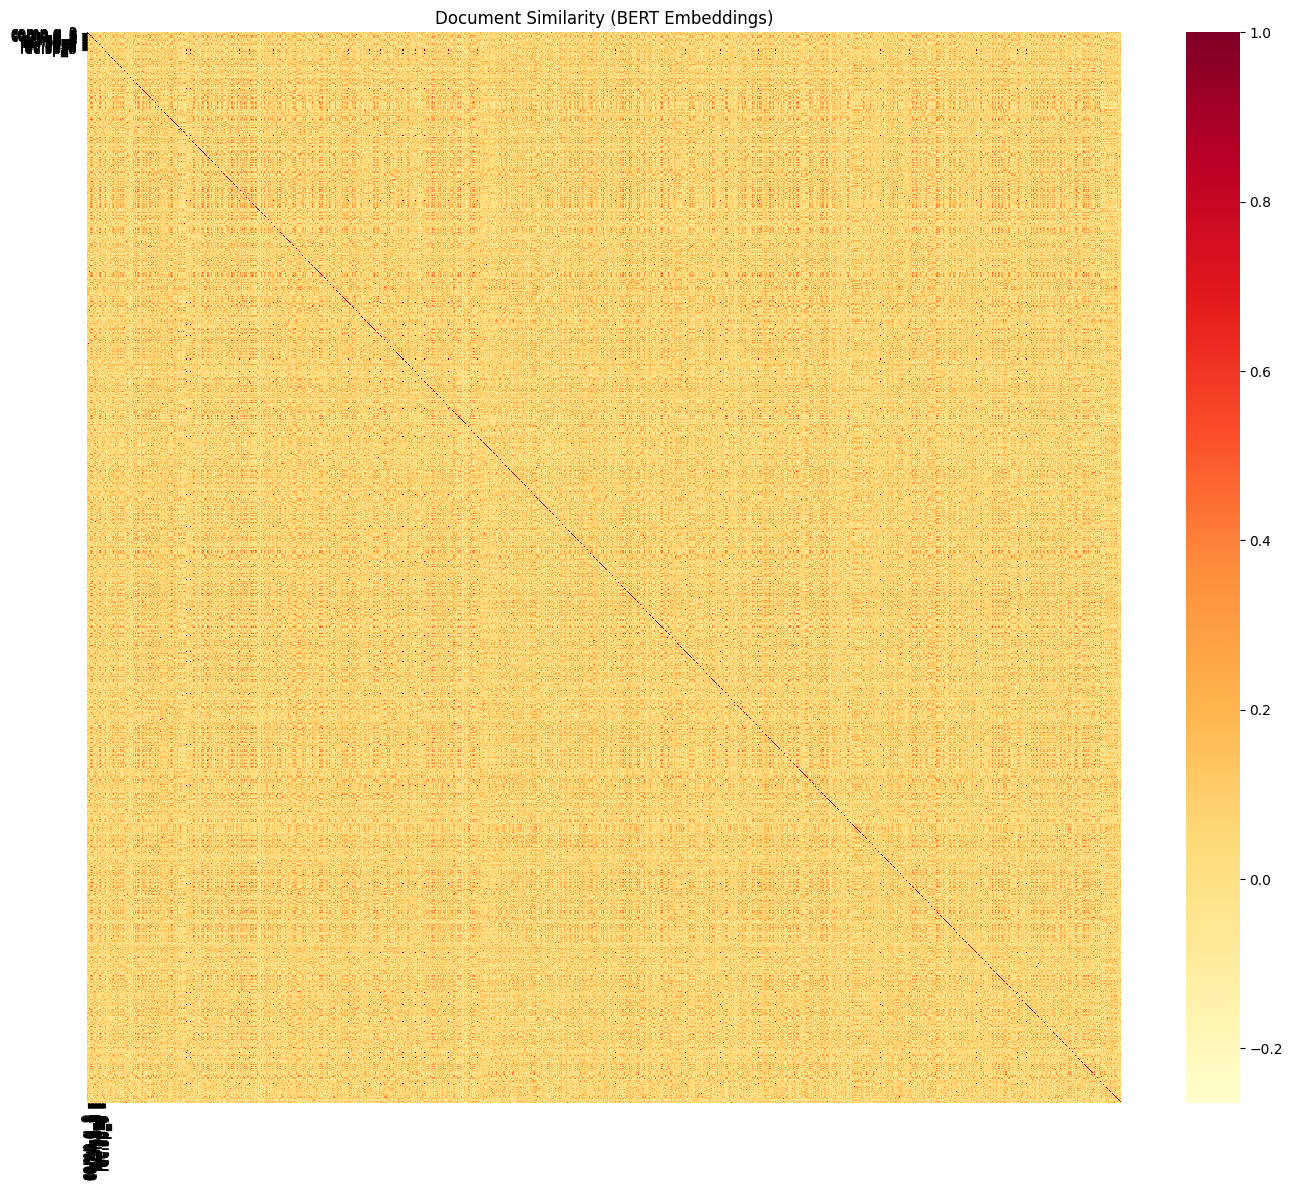

In [53]:
# Visualize BERT similarity matrix
import seaborn as sns

# Create labels
labels_short = [f"{l[:6]}_{i%10}" for i, l in enumerate(sampled_labels)]

plt.figure(figsize=(14, 12))
sns.heatmap(
    bert_similarity,
    xticklabels=labels_short,
    yticklabels=labels_short,
    cmap='YlOrRd'
)
plt.title('Document Similarity (BERT Embeddings)')
plt.tight_layout()
plt.savefig('bert_similarity_heatmap.png', dpi=150)
plt.show()

### Written Question C.1 (Personal Interpretation)

Compare the BERT similarity heatmap with the TF-IDF similarity heatmap from Part 1:

1. **Do documents cluster better by category with BERT or TF-IDF?**
2. **Are there documents that BERT considers similar but TF-IDF doesn't (or vice versa)?** Why might this happen?
3. **Which method would you use for a document classification task?** Explain your reasoning.

**YOUR ANSWER:**

1. Better clustering with: BERT because the documents tend to cluster better with BERT because it understands the meaning of the text, not only the words. TF-IDF only looks at word frequency, so it is more basic.

2. Differences between methods: BERT can find similarity between documents even if they use different words, because it understands meaning. TF-IDF may not see them as similar if they do not share the same words. Also, TF-IDF can think documents are similar just because they share many common words, even if the meaning is different.

3. Preferred method for classification: I would use BERT because it understands the meaning of the text and gives better similarity between documents. This helps to group documents by category more accurately. TF-IDF is faster and simpler, but BERT gives better results for understanding text.

### Exercise C.2: Semantic Search with BERT

In [54]:
from sklearn.metrics.pairwise import cosine_similarity

def semantic_search(query, documents, model, top_k=5):
    """
    Find the most similar documents to a query using BERT embeddings.
    """
    # 1. Encode the query
    query_embedding = model.encode([query])

    # 2. Encode all documents
    doc_embeddings = model.encode(documents)

    # 3. Compute similarity
    similarities = cosine_similarity(query_embedding, doc_embeddings)[0]

    # 4. Get top_k results
    top_indices = similarities.argsort()[-top_k:][::-1]

    return [(idx, similarities[idx]) for idx in top_indices]


# Test your search function
# Query related to your categories (example: space)
my_query = "nasa space mission satellite"

results = semantic_search(my_query, sampled_docs, sentence_model, top_k=5)

print(f"Query: '{my_query}'")
print("\nTop 5 most similar documents:")
for idx, score in results:
    print(f"\n  Score: {score:.4f}")
    print(f"  Category: {sampled_labels[idx]}")
    print(f"  Text: {sampled_docs[idx][:150]}...")

Query: 'nasa space mission satellite'

Top 5 most similar documents:

  Score: 0.2704
  Category: sci.space
  Text: 
Lets hear it for Dan Goldin...now if he can only convince the rest of
our federal government that the space program is a worth while
investment!

I h...

  Score: 0.2153
  Category: sci.space
  Text: I am doing a political science paper on the funding of NASA and pork-barrel 
politics.  I would be interested in information about funding practices a...

  Score: 0.1921
  Category: sci.space
  Text: From another space forum
    When workers at the Kennedy Space Center disassembled the STS-56
 solid rocket boosters they were surprised to find a pai...

  Score: 0.1688
  Category: sci.space
  Text: Sterrenkundig symposium 'Compacte Objecten'
                                             op 26 april 1993


In het jaar 1643, zeven jaar na de opricht...

  Score: 0.1678
  Category: sci.space
  Text: 

He's also the one who dubbed it the SR-71 - it was the RS-71 until LBJ
mippsel

### Written Question C.2 (Personal Interpretation)

Evaluate your semantic search results:

1. **Are the results relevant to your query?** Explain.
2. **Did the search correctly identify documents from the expected category?**
3. **Try a query that could match multiple categories. What happens?**

**YOUR ANSWER:**

1. Relevance: Yes, the results are relevant to the query. The query is about "nasa space mission satellite" and all the documents talk about space topics like NASA, space programs, and space centers. This shows that the model understands the meaning of the query

2. Category accuracy: Yes, all the results are from the "sci.space" category. This means the search worked correctly and found documents from the expected category.

3. Ambiguous query test: If we use a query that can match multiple categories, the results may include documents from different categories. This happens because BERT understands meaning, so it can connect the query to different topics if they are related.

---

## Part D: Embedding Visualization with t-SNE

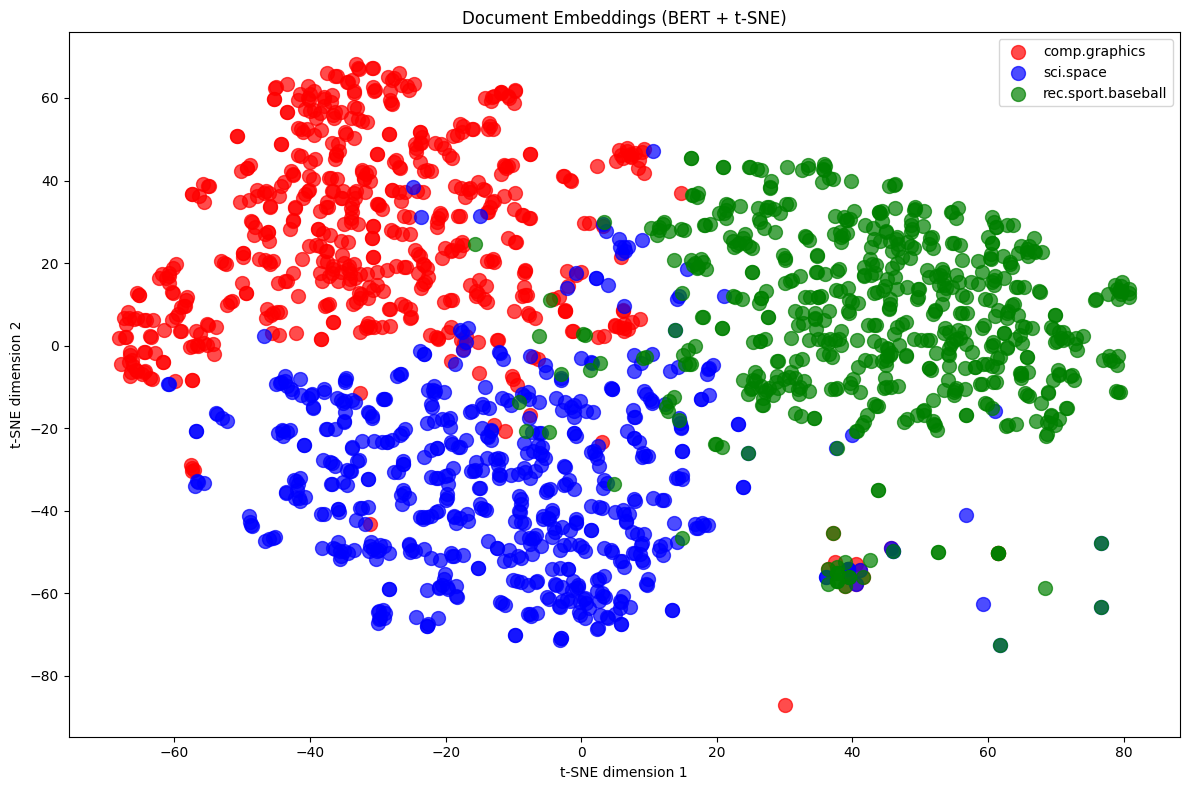

In [56]:
from sklearn.manifold import TSNE

# Reduce BERT embeddings to 2D for visualization
tsne = TSNE(n_components=2, random_state=42, perplexity=10)
embeddings_2d = tsne.fit_transform(doc_embeddings)

# Plot
plt.figure(figsize=(12, 8))

colors = {'comp.graphics': 'red', 'sci.space': 'blue', 'rec.sport.baseball': 'green'}  # Update with your categories
# Actually use your categories:
color_map = plt.cm.Set1

for category in my_categories:
    mask = df_filtered['label_text'] == category
    plt.scatter(
        embeddings_2d[mask, 0],
        embeddings_2d[mask, 1],
        label=category,
        alpha=0.7,
        s=100,
        c=colors[category]
    )

plt.legend()
plt.title('Document Embeddings (BERT + t-SNE)')
plt.xlabel('t-SNE dimension 1')
plt.ylabel('t-SNE dimension 2')
plt.tight_layout()
plt.savefig('tsne_document_embeddings.png', dpi=150)
plt.show()

### Written Question D.1 (Personal Interpretation)

Look at your t-SNE visualization:

1. **Do the categories form distinct clusters?**
2. **Are there any documents that appear in the "wrong" cluster?** What might explain this?
3. **Based on the visualization, which two categories are most similar?** Does this match your expectations from Part 1?

**YOUR ANSWER:**

1. Cluster quality: They do form different clusters, but there are still some values that are disperse.

2. Misplaced documents: Some documents appear in the wrong cluster. This can happen because some texts talk about topics that are similar to other categories, or they use similar words. Also, the model may not perfectly understand every document.

3. Most similar categories: The most similar categories seem to be comp.graphics and sci.space because both can include technical and scientific words. This matches expectations because in Part 1 they may share similar vocabulary and topics.

---

## Part E: Final Comparison and Reflection (10 min)

### Final Written Question (Comprehensive Reflection)

Based on everything you've learned in this lab:

1. **Create a comparison table** summarizing the strengths and weaknesses of each text representation method:
| Method | Strengths | Weaknesses | Best Use Case |
|--------|-----------|------------|---------------|
| BoW | ... | ... | ... |
| TF-IDF | ... | ... | ... |
| Word2Vec | ... | ... | ... |
| GloVe | ... | ... | ... |
| BERT | ... | ... | ... |

2. **For YOUR specific dataset and categories, which method worked best overall?**

3. **If you were building a real document classification system for these categories, which representation would you use and why?**

**YOUR ANSWER:**

### 1. Comparison Table

| Method | Strengths | Weaknesses | Best Use Case |
|--------|-----------|------------|---------------|
| BoW | Fast and simple | Doesn't understand the meaning and it ignores the order of the words | Basic word classification |
| TF-IDF | Highlights important words | Doesn't understand the meaning | Document similarity with keywords |
| Word2Vec | Learns word meaning from the contexts | Needs training data and has limited vocabulary | It is for specific tasks in small domains |
| GloVe | Pre-trained, good general meaning | Not specific for the dataset | General NLP tasks |
| BERT | Understands meanings very well | Slower and more complex | Semantic search and classification |

### 2. Best Method for My Dataset

BERT worked best for my dataset. In the similarity results and semantic search, it grouped documents correctly by category like "sci.space". It also found relevant documents even when the words were different. Other methods like TF-IDF and Word2Vec were more limited and sometimes gave less accurate results


### 3. My Recommendation for a Real System

I would use BERT because it understands the meaning of the text and gives better results for classification. It can group documents by category more accurately. Even if it is slower, it is more reliable for real applications.


---

## Summary - Lab 3

In this lab, you learned:

**Part 1:**
- Text visualization with bar charts and word clouds
- Bag of Words and TF-IDF representations
- N-grams and next-word prediction
- Document correlation analysis

**Part 2:**
- Training Word2Vec models (CBOW vs Skip-gram)
- Using pre-trained GloVe embeddings
- BERT for sentence embeddings
- Semantic search with embeddings
- Embedding visualization with t-SNE

---

## Final Submission Checklist

- [ ] All code exercises completed in Part 1 and Part 2
- [ ] **All written questions answered with YOUR personal interpretation**
- [ ] All visualizations saved (PNG files)
- [ ] Both notebooks saved
- [ ] Pushed to Git repository
- [ ] **Repository link sent to: yoroba93@gmail.com**

### Reminder: Oral Defense

Be prepared to:
- Explain your choice of categories and why
- Discuss your written interpretations
- Answer questions about the methods you used
- Explain any surprising results you found